In [2]:
# ===== Cell 1: setup & config =====
import os, json, re, collections, math, random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as T

# Repro
SEED = 1337
random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---- Paths (EDIT if needed) ----
ROOT = "PartImageNet_Seg/PartImageNet"                 # folder containing 'annotations' and 'images'
TRAIN_ANN = "annotations/train/train.json"
TEST_ANN  = "annotations/test/test.json"
# (Optional) VAL_ANN if you have it
VAL_ANN   = "annotations/val/val.json"

TRAIN_IMG_ROOT = "images/train"
TEST_IMG_ROOT  = "images/test"
VAL_IMG_ROOT   = "images/val"

# ---- AlexNet / ImageNet transforms ----
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.8, 1.2)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Minimum crop size in pixels (width/height); use 12+ to skip tiny boxes
MIN_SIZE = 12


Device: cuda


In [3]:
# ===== Cell 2: dataset, global clusters, loaders =====

FILE_KEYS  = ["file_name","fileName","path","image","name"]
CATID_KEYS = ["category_id","categoryId","object_category_id","obj_cat"]
BBOX_KEYS  = ["bbox","bBox","box"]
SEG_KEYS   = ["segmentation","seg","polygon"]

def _find_any(d, keys):
    for k in keys:
        if k in d: return d[k]
    return None

def _derive_part_from_category_name(cat_name: str) -> str:
    if not cat_name: return "misc"
    s = re.sub(r"[-_]+", " ", str(cat_name).strip().lower())
    toks = s.split()
    return toks[-1] if toks else "misc"

def _box_from_poly(poly):
    xs = poly[0::2]; ys = poly[1::2]
    return [float(min(xs)), float(min(ys)), float(max(xs)-min(xs)), float(max(ys)-min(ys))]

def pil_crop_from_ann(img: Image.Image, ann: dict):
    bx = _find_any(ann, BBOX_KEYS)
    if bx is None:
        seg = _find_any(ann, SEG_KEYS)
        if seg and isinstance(seg, list) and len(seg) > 0:
            poly = seg[0] if isinstance(seg[0], list) else seg
            bx = _box_from_poly(poly)
        else:
            return None
    if isinstance(bx, dict):
        x,y,w,h = float(bx.get("x",0)), float(bx.get("y",0)), float(bx.get("width",0)), float(bx.get("height",0))
    else:
        x,y,w,h = map(float, bx)
    x0, y0 = int(max(0, x)), int(max(0, y))
    x1, y1 = int(min(img.width, x+w)), int(min(img.height, y+h))
    if x1 <= x0 or y1 <= y0: return None
    return img.crop((x0, y0, x1, y1))

def resolve_path(root: str, images_root: str, fn: str) -> Optional[str]:
    base = Path(root)
    imroot = base / images_root if images_root else base
    candidates = [
        imroot / fn,
        imroot / "jpegs" / fn,
        base / fn,
    ]
    for p in candidates:
        if p.exists(): return str(p)
    return None

def build_global_clusters(root: str, ann_paths: List[str]) -> Dict[str, List[str]]:
    """part_token -> sorted list of ORIGINAL category names (global vocab across splits)"""
    by_part = collections.defaultdict(set)
    for rel in ann_paths:
        p = os.path.join(root, rel)
        if not os.path.exists(p): continue
        J = json.load(open(p, "r"))
        for c in J.get("categories", []):
            nm = str(c.get("name","")).strip()
            if not nm: continue
            by_part[_derive_part_from_category_name(nm)].add(nm)
    return {part: sorted(names) for part, names in by_part.items()}

GLOBAL_CLUSTERS = build_global_clusters(ROOT, [TRAIN_ANN, TEST_ANN, VAL_ANN])
CANONICAL_PARTS = sorted(GLOBAL_CLUSTERS.keys())
PART_TO_IDX = {p:i for i,p in enumerate(CANONICAL_PARTS)}
print("Discovered parts:", CANONICAL_PARTS)

class PartExample:
    def __init__(self, img_path, part_canonical, cluster_name, bbox_or_seg_ann, image_id):
        self.img_path = img_path
        self.part_canonical = part_canonical   # e.g., "wing", "tier", "head"
        self.cluster_name = cluster_name       # original category name, e.g., "Bird Wing"
        self.bbox_or_seg_ann = bbox_or_seg_ann
        self.image_id = image_id

class PartCropDataset2(Dataset):
    """
    Crops RGB from bbox or polygon; routes by last token of category name (data-driven parts).
    Clusters are ORIGINAL category names, but indices are from a GLOBAL map (consistent across splits).
    """
    def __init__(self, root: str, json_path: str, images_root: str, transform=None, min_size: int = 12, global_clusters=None):
        super().__init__()
        self.root, self.images_root = root, images_root
        self.transform = transform or eval_tf
        self.min_size = min_size
        self.global_clusters = global_clusters or GLOBAL_CLUSTERS

        J = json.load(open(os.path.join(root, json_path), "r"))
        self.cat_map = {int(c["id"]): c for c in J.get("categories", []) if "id" in c}

        # image_id -> resolved file path
        self.image_map = {}
        for im in J.get("images", []):
            fn = _find_any(im, FILE_KEYS)
            if not fn: continue
            im_id = im.get("id", im.get("image_id", len(self.image_map)))
            full = resolve_path(root, images_root, fn)
            if full: self.image_map[im_id] = full

        # items
        items = []
        miss_path = miss_cat = tiny_box = 0
        for a in J.get("annotations", []):
            img_id = a.get("image_id", a.get("id"))
            full = self.image_map.get(img_id)
            if not full or not os.path.exists(full): miss_path += 1; continue

            cid = _find_any(a, CATID_KEYS)
            cat = self.cat_map.get(int(cid), {}) if cid is not None else {}
            cat_name = cat.get("name"); supercat = cat.get("supercategory")
            if not cat_name and not supercat: miss_cat += 1; continue

            part = _derive_part_from_category_name(cat_name)
            cluster_name = cat_name or supercat or str(cid)

            # filter tiny boxes if bbox present
            bx = _find_any(a, BBOX_KEYS)
            if bx is not None:
                if isinstance(bx, dict):
                    w = float(bx.get("width", 0)); h = float(bx.get("height", 0))
                else:
                    try:
                        _,_,w,h = bx
                        w,h = float(w), float(h)
                    except Exception:
                        w = h = 0
                if (w < self.min_size) or (h < self.min_size):
                    tiny_box += 1; continue

            items.append(PartExample(full, part, str(cluster_name), a, img_id))

        self.items: List[PartExample] = items

        # Build detector_clusters with the provided global order
        self.detector_clusters: Dict[str, Dict[str,int]] = {
            p: {name:i for i, name in enumerate(self.global_clusters.get(p, []))}
            for p in CANONICAL_PARTS
        }

        # Count OOV (cluster names present in items but not in global map)
        self.oov_counts = {}
        for it in self.items:
            if it.cluster_name not in self.detector_clusters.get(it.part_canonical, {}):
                self.oov_counts[it.part_canonical] = self.oov_counts.get(it.part_canonical, 0) + 1

        print(f"[PartCropDataset2] images={len(self.image_map)} items={len(self.items)} "
              f"miss_path={miss_path} miss_cat={miss_cat} tiny_box={tiny_box}")
        if self.oov_counts:
            print("OOV cluster labels found (ignored at __getitem__):", self.oov_counts)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it.img_path).convert("RGB")
        crop = pil_crop_from_ann(img, it.bbox_or_seg_ann)
        if crop is None:
            # fallback black chip (should be rare)
            crop = Image.new("RGB", (224,224), (0,0,0))
        x = self.transform(crop)

        det_idx = PART_TO_IDX.get(it.part_canonical, 0)
        cluster_idx = self.detector_clusters.get(it.part_canonical, {}).get(it.cluster_name, -1)
        return x, det_idx, cluster_idx, it.image_id

# ---- Instantiate datasets ----
ds_tr = PartCropDataset2(ROOT, TRAIN_ANN, TRAIN_IMG_ROOT, transform=train_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
ds_te = PartCropDataset2(ROOT, TEST_ANN,  TEST_IMG_ROOT,  transform=eval_tf,   min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)

print("num part-crops (train):", len(ds_tr))
print("num part-crops (test): ", len(ds_te))
print("parts:", CANONICAL_PARTS)
for p in CANONICAL_PARTS:
    print(f"{p:10s} -> {len(ds_tr.detector_clusters[p])} classes")


Discovered parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']
[PartCropDataset2] images=20466 items=90451 miss_path=0 miss_cat=0 tiny_box=4608
[PartCropDataset2] images=2408 items=10715 miss_path=0 miss_cat=0 tiny_box=560
num part-crops (train): 90451
num part-crops (test):  10715
parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']
body       -> 11 classes
engine     -> 1 classes
fin        -> 1 classes
foot       -> 4 classes
hand       -> 1 classes
head       -> 8 classes
mirror     -> 1 classes
mouth      -> 1 classes
sail       -> 1 classes
seat       -> 1 classes
tail       -> 6 classes
tier       -> 2 classes
wing       -> 2 classes


In [4]:
# ===== Cell 3: AlexNet models, early stopping, training, fusion, head =====

# --- torchvision AlexNet (guarded) ---
try:
    from torchvision.models import alexnet, AlexNet_Weights
except Exception:
    alexnet, AlexNet_Weights = None, None

def _device() -> torch.device:
    return DEVICE

def _acc(logits: torch.Tensor, y: torch.Tensor) -> float:
    if logits is None or logits.numel() == 0: return 0.0
    return (logits.argmax(1) == y).float().mean().item()

def _class_weights(counts: List[int]) -> torch.Tensor:
    tot = float(sum(counts)) + 1e-8
    inv = [tot / (c if c > 0 else 1.0) for c in counts]
    w = torch.tensor(inv, dtype=torch.float32)
    return w / w.mean()

def _weighted_sampler(labels: List[int], K: int) -> WeightedRandomSampler:
    counts = [0]*K
    for y in labels: counts[int(y)] += 1
    inv = [1.0 / (c if c > 0 else 1.0) for c in counts]
    weights = [inv[int(y)] for y in labels]
    return WeightedRandomSampler(torch.tensor(weights, dtype=torch.double), num_samples=len(labels), replacement=True)

# ---- Early stopper ----
class EarlyStopper:
    def __init__(self, monitor: str = "val_acc", patience: int = 8, min_delta: float = 1e-3):
        self.monitor = monitor
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad_epochs = 0
        self.mode = "max" if monitor == "val_acc" else "min"
    def step(self, current: Optional[float]) -> bool:
        if current is None: return False
        if self.best is None:
            self.best = current; self.bad_epochs = 0; return False
        improved = (current - self.best) > self.min_delta if self.mode == "max" else (self.best - current) > self.min_delta
        if improved:
            self.best = current; self.bad_epochs = 0; return False
        self.bad_epochs += 1
        return self.bad_epochs > self.patience

# ---- AlexNet backbone + detector head ----
class AlexBackbone(nn.Module):
    """TorchVision AlexNet.features + AdaptiveAvgPool2d((6,6)) -> 9216-d vec."""
    def __init__(self, trainable: bool = False, weights: Optional[str] = "imagenet"):
        super().__init__()
        if alexnet is None:
            raise RuntimeError("torchvision.models.alexnet() unavailable.")
        tv_w = None
        if weights == "imagenet" and AlexNet_Weights is not None:
            try: tv_w = AlexNet_Weights.IMAGENET1K_V1
            except Exception: tv_w = None
        m = alexnet(weights=tv_w)
        self.features = m.features
        self.avgpool  = m.avgpool
        for p in self.features.parameters(): p.requires_grad = bool(trainable)
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)   # (B,256,6,6)
        return x.flatten(1)   # (B,9216)

class PartDetectorAlexNet(nn.Module):
    """Backbone (frozen by default) + small MLP emb + classifier."""
    def __init__(self, emb_dim: int, num_classes: int, backbone_trainable: bool = False, weights: Optional[str] = "imagenet"):
        super().__init__()
        self.backbone = AlexBackbone(trainable=backbone_trainable, weights=weights)
        self.emb = nn.Sequential(
            nn.Linear(256*6*6, emb_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )
        self.cls = nn.Linear(emb_dim, num_classes)
    def forward(self, x):
        f = self.backbone(x)
        z = self.emb(f)
        logits = self.cls(z)
        return z, logits

# ---- Per-detector training with early stopping ----
def train_single_detector(
    part_name: str,
    ds_train: Dataset, ds_val: Optional[Dataset],
    clusters_map: Dict[str,int],          # TRAIN map: {cluster_name -> idx}
    emb_dim: int = 128,
    epochs: int = 50,
    batch_size: int = 256,
    lr: float = 3e-4,
    backbone_trainable: bool = False,
    weights: Optional[str] = "imagenet",
    use_amp: bool = True,
    num_workers: int = 0,
    early_stop: bool = True,
    patience: int = 8,
    min_delta: float = 1e-3,
):
    device = _device()
    K = max(clusters_map.values()) + 1 if clusters_map else 0
    assert K >= 1, f"[{part_name}] no classes to train."

    # Build filtered datasets
    class PartOnly(Dataset):
        def __init__(self, base_ds, part): self.base=base_ds; self.ids=[i for i,it in enumerate(base_ds.items) if it.part_canonical==part]
        def __len__(self): return len(self.ids)
        def __getitem__(self,i): return self.base[self.ids[i]]
    tr = PartOnly(ds_train, part_name)
    vl = PartOnly(ds_val,   part_name) if ds_val is not None else None

    # Train labels (for sampler & priors)
    y_tr = [int(tr[i][2]) for i in range(len(tr)) if tr[i][2] >= 0]
    assert len(y_tr) > 0, f"[{part_name}] no valid training labels."
    sampler = _weighted_sampler(y_tr, K)
    tr_loader = DataLoader(tr, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=True)
    vl_loader = DataLoader(vl, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True) if (vl and len(vl)>0) else None

    model = PartDetectorAlexNet(emb_dim=emb_dim, num_classes=K, backbone_trainable=backbone_trainable, weights=weights).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)

    # Weighted CE (+ smoothing if supported)
    counts = [0]*K
    for y in y_tr: counts[y] += 1
    cw = _class_weights(counts).to(device)
    try: criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
    except TypeError: criterion = nn.CrossEntropyLoss(weight=cw)

    # LR scheduler (older torch: no 'verbose' kwarg)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type=="cuda"))
    stopper = EarlyStopper(monitor="val_acc", patience=patience, min_delta=min_delta) if early_stop else None

    logs = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "best_epoch": None, "best_val_acc": None}
    best_state = None; best_ep = -1; best_va = -1.0

    # helper: remap val indices by ORIGINAL NAME → TRAIN index (no-op if maps already match)
    inv_val_cache = None
    def remap_val(yb_val: torch.Tensor) -> torch.Tensor:
        nonlocal inv_val_cache
        if inv_val_cache is None and ds_val is not None:
            inv_val_cache = {v:k for k,v in ds_val.detector_clusters.get(part_name, {}).items()}
        if inv_val_cache is None: return yb_val
        out = []
        for y in yb_val.tolist():
            if int(y) < 0: out.append(-1); continue
            nm = inv_val_cache.get(int(y))
            out.append(clusters_map.get(nm, -1))
        return torch.tensor(out, device=yb_val.device, dtype=torch.long)

    for ep in range(1, epochs+1):
        # ---- train ----
        model.train(); tl=ta=0.0; nbt=0
        for xb, _, yb, _ in tr_loader:
            m = (yb >= 0)
            if m.sum().item()==0: continue
            xb = xb[m].to(device, non_blocking=True); yb = yb[m].to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(use_amp and device.type=="cuda")):
                _, logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += float(loss.item()); ta += _acc(logits, yb); nbt += 1
        tr_loss, tr_acc = tl/max(1,nbt), ta/max(1,nbt)
        logs["train_loss"].append(tr_loss); logs["train_acc"].append(tr_acc)

        # ---- val ----
        if vl_loader is not None:
            model.eval(); vl_sum=va_sum=0.0; nvb=0
            with torch.no_grad(), torch.cuda.amp.autocast(enabled=(use_amp and device.type=="cuda")):
                for xb, _, yb_val, _ in vl_loader:
                    yb = remap_val(yb_val)
                    m = (yb >= 0)
                    if m.sum().item()==0: continue
                    xb = xb[m].to(device); yb = yb[m].to(device)
                    _, logits = model(xb)
                    vloss = criterion(logits, yb)
                    vl_sum += float(vloss.item()); va_sum += _acc(logits, yb); nvb += 1
            val_loss, val_acc = vl_sum/max(1,nvb), va_sum/max(1,nvb)
            logs["val_loss"].append(val_loss); logs["val_acc"].append(val_acc)
            scheduler.step(val_loss)

            # track best
            if val_acc > best_va + min_delta:
                best_va, best_ep = val_acc, ep
                best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
                logs["best_epoch"], logs["best_val_acc"] = best_ep, best_va

            print(f"[{part_name}] ep {ep:02d}/{epochs}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}  lr={opt.param_groups[0]['lr']:.2e}")

            if stopper and stopper.step(val_acc):
                print(f"[{part_name}] early stop at epoch {ep} (best ep {best_ep} val_acc={best_va:.3f})")
                break
        else:
            logs["val_loss"].append(None); logs["val_acc"].append(None)
            print(f"[{part_name}] ep {ep:02d}/{epochs}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state, strict=True)

    # Priors (for gating)
    priors = torch.tensor(counts, dtype=torch.float32)
    priors = priors / priors.sum().clamp_min(1e-6)

    state = {
        "part": part_name,
        "state_dict": model.state_dict(),
        "emb_dim": emb_dim,
        "num_classes": K,
        "clusters": clusters_map,
        "inv_clusters": {v:k for k,v in clusters_map.items()},
        "priors": priors.tolist(),
        "logs": logs,
    }
    return model, state

def train_alex_detectors(
    ds_train: Dataset,
    ds_val: Optional[Dataset],
    outdir: str = "alex_ckpts",
    emb_dim: int = 128,
    epochs: int = 50,
    batch_size: int = 256,
    lr: float = 3e-4,
    backbone_trainable: bool = False,
    weights: Optional[str] = "imagenet",  # set to None if you don't have cached weights
    use_amp: bool = True,
    num_workers: int = 0,
    early_stop: bool = True,
    patience: int = 8,
    min_delta: float = 1e-3,
):
    os.makedirs(outdir, exist_ok=True)
    parts = sorted({it.part_canonical for it in ds_train.items})
    manifest = {"parts": parts, "emb_dim": emb_dim, "detectors": []}
    for part in parts:
        clusters_map = ds_train.detector_clusters.get(part, {})
        if len(clusters_map) < 1:
            print(f"[{part}] skipped (0 classes)."); continue
        print(f"==> Training '{part}' with {len(clusters_map)} classes (ES={early_stop}, epochs={epochs})")
        model, state = train_single_detector(
            part, ds_train, ds_val, clusters_map,
            emb_dim=emb_dim, epochs=epochs, batch_size=batch_size, lr=lr,
            backbone_trainable=backbone_trainable, weights=weights, use_amp=use_amp,
            num_workers=num_workers, early_stop=early_stop, patience=patience, min_delta=min_delta
        )
        torch.save(state, os.path.join(outdir, f"det_{part}.pt"))
        manifest["detectors"].append({"part": part, "file": f"det_{part}.pt"})
    json.dump(manifest, open(os.path.join(outdir, "manifest.json"), "w"), indent=2)
    print(f"Saved {len(manifest['detectors'])} detectors to: {outdir}")

# ---- Ensemble + Fusion (likelihood × priors gating) ----
class PartEnsembleAlex:
    def __init__(self, ckpt_dir: str, device: Optional[torch.device] = None):
        self.device = device or _device()
        man = json.load(open(os.path.join(ckpt_dir, "manifest.json"), "r"))
        self.parts: List[str] = man["parts"]
        self.emb_dim: int = man["emb_dim"]
        self.detectors: List[PartDetectorAlexNet] = []
        self.inv_clusters: List[Dict[int,str]] = []
        self.priors: List[torch.Tensor] = []
        self.part_names_in_order: List[str] = []
        for d in man["detectors"]:
            state = torch.load(os.path.join(ckpt_dir, d["file"]), map_location=self.device)
            m = PartDetectorAlexNet(emb_dim=state["emb_dim"], num_classes=state["num_classes"])
            m.load_state_dict(state["state_dict"], strict=True)
            m.to(self.device).eval()
            self.detectors.append(m)
            self.inv_clusters.append(state["inv_clusters"])
            self.priors.append(torch.tensor(state["priors"], dtype=torch.float32, device=self.device))
            self.part_names_in_order.append(state["part"])
    def score_all(self, x: torch.Tensor):
        zs, logits = [], []
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=(self.device.type=="cuda")):
            for d in self.detectors:
                z, lg = d(x)
                zs.append(z); logits.append(lg)
        return zs, logits

def fuse_image_embeddings(ds: Dataset, ens: PartEnsembleAlex, batch_size: int = 128):
    device = ens.device
    by_img = collections.defaultdict(list)
    for i, it in enumerate(ds.items):
        by_img[it.image_id].append(i)
    image_ids = sorted(by_img.keys())

    rows = []
    for iid in image_ids:
        idxs = by_img[iid]
        per_part = {p: [] for p in ens.part_names_in_order}
        for s in range(0, len(idxs), batch_size):
            chunk = idxs[s:s+batch_size]
            xb = torch.cat([ds[j][0].unsqueeze(0) for j in chunk], 0).to(device, non_blocking=True)
            zs_list, lg_list = ens.score_all(xb)
            softs = [F.softmax(lg, 1) if lg is not None else None for lg in lg_list]
            scores = []
            for d, sf in enumerate(softs):
                if sf is None:
                    scores.append(torch.zeros(xb.size(0), device=device)); continue
                sc = (sf * ens.priors[d].view(1, -1)).sum(1)   # likelihood × prior
                scores.append(sc)
            S = torch.stack(scores, 0).transpose(0,1)          # (B, D)
            winners = S.argmax(1).tolist()
            for bi, d_idx in enumerate(winners):
                pn = ens.part_names_in_order[d_idx]
                per_part[pn].append(zs_list[d_idx][bi].detach().cpu())
        # mean per part; zeros if absent
        feats = []
        for pn in ens.part_names_in_order:
            if len(per_part[pn]) == 0:
                feats.append(torch.zeros(ens.emb_dim))
            else:
                feats.append(torch.stack(per_part[pn], 0).mean(0))
        rows.append(torch.cat(feats, 0))
    X = torch.stack(rows, 0)
    return X, image_ids

# ---- Image labels (majority supercategory) & final head (with ES) ----
def image_labels_from_supercategory(ds: Dataset, image_ids: List[int], label_map: Optional[Dict[str,int]] = None):
    anns_by_img = collections.defaultdict(list)
    for it in ds.items:
        anns_by_img[it.image_id].append(it.bbox_or_seg_ann)
    names = []
    for iid in image_ids:
        cats = []
        for a in anns_by_img[iid]:
            cid = a.get("category_id")
            if cid is None: continue
            cat = ds.cat_map.get(int(cid), {})
            sc = cat.get("supercategory")
            if sc: cats.append(sc)
        names.append(collections.Counter(cats).most_common(1)[0][0] if cats else "Unknown")
    if label_map is None:
        uniq = sorted(set(names))
        label_map = {n:i for i,n in enumerate(uniq)}
    y = torch.tensor([label_map.get(n, -1) for n in names], dtype=torch.long)
    return y, label_map

class LinearHead(nn.Module):
    def __init__(self, in_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)
    def forward(self, x): return self.fc(x)

def train_linear_head(
    Xtr: torch.Tensor, ytr: torch.Tensor,
    Xte: torch.Tensor, yte: torch.Tensor,
    epochs: int = 50, lr: float = 5e-3, wd: float = 1e-4,
    early_stop: bool = True, patience: int = 8, min_delta: float = 1e-3
):
    device = _device()
    C = int(ytr.max().item()) + 1
    model = LinearHead(Xtr.shape[1], C).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    try: crit = nn.CrossEntropyLoss(label_smoothing=0.05)
    except TypeError: crit = nn.CrossEntropyLoss()

    Xtr, ytr, Xte, yte = Xtr.to(device), ytr.to(device), Xte.to(device), yte.to(device)
    logs = {"loss": [], "val_acc": [], "best_epoch": None, "best_val_acc": None}
    stopper = EarlyStopper(monitor="val_acc", patience=patience, min_delta=min_delta) if early_stop else None
    best_state, best_va, best_ep = None, -1.0, -1

    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad(set_to_none=True)
        loss = crit(model(Xtr), ytr)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            va = _acc(model(Xte), yte)
        logs["loss"].append(float(loss.item())); logs["val_acc"].append(va)

        if va > best_va + min_delta:
            best_va, best_ep = va, ep
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            logs["best_epoch"], logs["best_val_acc"] = best_ep, best_va

        print(f"[Head] Epoch {ep}/{epochs} loss={loss.item():.4f} val_acc={va:.3f}")

        if stopper and stopper.step(va):
            print(f"[Head] early stop at epoch {ep} (best ep {best_ep} val_acc={best_va:.3f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state, strict=True)
    return model, logs


In [6]:
# ===== Cell 4: run training (50 ep + early stop), fuse, final head =====

# 1) Train AlexNet-based detectors (frozen backbone, AMP, ES)
train_alex_detectors(
    ds_train=ds_tr,
    ds_val=ds_te,                 # use test as val for fast iterations
    outdir="alex_ckpts",
    emb_dim=128,
    epochs=50,                    # up to 50; ES will cut it short if not improving
    batch_size=256,
    lr=3e-4,
    backbone_trainable=False,     # set True ONLY for the biggest parts if you want extra accuracy
    weights="imagenet",           # set to None if you don't have cached weights
    use_amp=True,
    num_workers=0,
    early_stop=True, patience=8, min_delta=1e-3,
)

# 2) Fuse crops → image vectors by likelihood×prior routing
ens = PartEnsembleAlex("alex_ckpts")
Xtr, ids_tr = fuse_image_embeddings(ds_tr, ens, batch_size=256)
Xte, ids_te = fuse_image_embeddings(ds_te, ens, batch_size=256)
print("Fused:", Xtr.shape, Xte.shape)

# 3) Build image-level labels (majority supercategory) & train final linear head (ES)
ytr, label_map = image_labels_from_supercategory(ds_tr, ids_tr)
yte, _ = image_labels_from_supercategory(ds_te, ids_te, label_map=label_map)

head, head_logs = train_linear_head(
    Xtr, ytr, Xte, yte,
    epochs=50, lr=5e-3, wd=1e-4,
    early_stop=True, patience=8, min_delta=1e-3
)


==> Training 'body' with 11 classes (ES=True, epochs=50)


/tmp/ipykernel_49501/2474874335.py:133: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type=="cuda"))
/tmp/ipykernel_49501/2474874335.py:161: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type=="cuda")):
/tmp/ipykernel_49501/2474874335.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(use_amp and device.type=="cuda")):


[body] ep 01/50  tr_loss=0.9364 tr_acc=0.626  val_loss=2.1632 val_acc=0.501  lr=3.00e-04
[body] ep 02/50  tr_loss=0.7231 tr_acc=0.762  val_loss=2.0657 val_acc=0.572  lr=3.00e-04
[body] ep 03/50  tr_loss=0.6660 tr_acc=0.798  val_loss=2.0734 val_acc=0.583  lr=3.00e-04
[body] ep 04/50  tr_loss=0.6372 tr_acc=0.816  val_loss=2.0544 val_acc=0.575  lr=3.00e-04
[body] ep 05/50  tr_loss=0.6219 tr_acc=0.831  val_loss=2.0198 val_acc=0.607  lr=3.00e-04
[body] ep 06/50  tr_loss=0.6065 tr_acc=0.844  val_loss=2.0435 val_acc=0.602  lr=3.00e-04
[body] ep 07/50  tr_loss=0.5963 tr_acc=0.850  val_loss=2.0177 val_acc=0.613  lr=3.00e-04
[body] ep 08/50  tr_loss=0.5886 tr_acc=0.860  val_loss=1.9755 val_acc=0.652  lr=3.00e-04
[body] ep 09/50  tr_loss=0.5812 tr_acc=0.863  val_loss=1.9972 val_acc=0.635  lr=3.00e-04
[body] ep 10/50  tr_loss=0.5676 tr_acc=0.871  val_loss=2.0080 val_acc=0.622  lr=3.00e-04
[body] ep 11/50  tr_loss=0.5695 tr_acc=0.875  val_loss=2.0112 val_acc=0.630  lr=1.50e-04
[body] ep 12/50  tr_l

/tmp/ipykernel_49501/2474874335.py:277: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(self.device.type=="cuda")):


Fused: torch.Size([20451, 1664]) torch.Size([2403, 1664])
[Head] Epoch 1/50 loss=2.3851 val_acc=0.152
[Head] Epoch 2/50 loss=2.2731 val_acc=0.251
[Head] Epoch 3/50 loss=2.1864 val_acc=0.312
[Head] Epoch 4/50 loss=2.1198 val_acc=0.299
[Head] Epoch 5/50 loss=2.0695 val_acc=0.299
[Head] Epoch 6/50 loss=2.0333 val_acc=0.299
[Head] Epoch 7/50 loss=2.0089 val_acc=0.299
[Head] Epoch 8/50 loss=1.9927 val_acc=0.299
[Head] Epoch 9/50 loss=1.9806 val_acc=0.299
[Head] Epoch 10/50 loss=1.9689 val_acc=0.299
[Head] Epoch 11/50 loss=1.9554 val_acc=0.299
[Head] Epoch 12/50 loss=1.9397 val_acc=0.300
[Head] early stop at epoch 12 (best ep 3 val_acc=0.312)


In [9]:
# 2) Fuse crops → image vectors by likelihood×prior routing
ens = PartEnsembleAlex("alex_ckpts")
Xtr, ids_tr = fuse_image_embeddings(ds_tr, ens, batch_size=256)
Xte, ids_te = fuse_image_embeddings(ds_te, ens, batch_size=256)
print("Fused:", Xtr.shape, Xte.shape)

# 3) Build image-level labels (majority supercategory) & train final linear head (ES)
ytr, label_map = image_labels_from_supercategory(ds_tr, ids_tr)
yte, _ = image_labels_from_supercategory(ds_te, ids_te, label_map=label_map)

/tmp/ipykernel_1125/2474874335.py:277: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(self.device.type=="cuda")):


Fused: torch.Size([20451, 1664]) torch.Size([2403, 1664])


In [10]:
# ---- PCA to 2D (no sklearn) ----
import torch, numpy as np, matplotlib.pyplot as plt
from collections import defaultdict

def pca_2d(tensor_2d: torch.Tensor):
    """
    tensor_2d: [N, D] torch float
    returns: Z [N,2]  (centered, projected onto top-2 PCs)
    """
    X = tensor_2d.detach().float()
    X = X - X.mean(0, keepdim=True)
    # economy SVD
    U, S, Vh = torch.linalg.svd(X, full_matrices=False)
    comps = Vh[:2].T  # [D,2]
    Z = X @ comps     # [N,2]
    return Z

def sample_part_items(ds, part_name, max_per_cluster=300):
    """
    Selects up to max_per_cluster items for each original cluster name
    within the given 'part_name'. Returns list of dataset indices.
    """
    # collect indices per cluster
    by_cluster = defaultdict(list)
    for i, it in enumerate(ds.items):
        if it.part_canonical != part_name: 
            continue
        # skip OOV clusters that weren't in the global map
        cl_map = ds.detector_clusters.get(part_name, {})
        if it.cluster_name not in cl_map: 
            continue
        by_cluster[it.cluster_name].append(i)

    # sample (deterministic)
    rng = np.random.default_rng(1337)
    picked = []
    for cname, idxs in by_cluster.items():
        if len(idxs) > max_per_cluster:
            idxs = list(rng.choice(idxs, size=max_per_cluster, replace=False))
        picked.extend(idxs)
    return picked, sorted(by_cluster.keys())

def embed_with_detector(ds, ens, part_name, idxs, batch_size=512):
    """
    Runs the detector for `part_name` over the selected crop indices and returns:
      - Z: embeddings [N, emb_dim]
      - y_true: cluster indices (train/global map indices) [N]
      - names_true: cluster names (len N list)
    """
    device = ens.device
    # locate the detector index for this part
    part_to_idx = {p:i for i,p in enumerate(ens.part_names_in_order)}
    if part_name not in part_to_idx:
        raise ValueError(f"Detector for part '{part_name}' not found in ensemble.")
    d_idx = part_to_idx[part_name]
    det = ens.detectors[d_idx].eval()

    feats, y_true, names_true = [], [], []
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        for s in range(0, len(idxs), batch_size):
            chunk = idxs[s:s+batch_size]
            xb = torch.cat([ds[j][0].unsqueeze(0) for j in chunk], 0).to(device, non_blocking=True)

            # forward only the target detector (fast)
            z, logits = det(xb)

            feats.append(z.detach().cpu())
            # get the true cluster indices for this part from ds
            for j in chunk:
                _, _, cidx, _ = ds[j]
                y_true.append(int(cidx))
                # name for legend
                it = ds.items[j]
                names_true.append(it.cluster_name)

    Z = torch.cat(feats, 0)
    y_true = torch.tensor(y_true, dtype=torch.long)
    return Z, y_true, names_true

def plot_density(Z2: np.ndarray, title: str, bins=180, annotate_points=None):
    """
    Z2: [N,2] numpy
    annotate_points: list of (x,y,label) to overlay cluster centroids (optional)
    """
    # 2D histogram
    x = Z2[:,0]; y = Z2[:,1]
    H, xedges, yedges = np.histogram2d(x, y, bins=bins)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    plt.figure(figsize=(5.3, 5.3))
    plt.imshow(H.T, origin='lower', extent=extent, aspect='equal')  # density map
    if annotate_points:
        for (cx, cy, lab) in annotate_points:
            plt.scatter([cx], [cy], s=16)
            plt.text(cx, cy, lab, fontsize=8)
    plt.title(title)
    plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.tight_layout()
    plt.show()


In [11]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_cluster_contours_or_scatter(
    Z2: np.ndarray, labels: np.ndarray, label_names: dict,
    bins=160, sigma_bins=1.0, levels=(0.3, 0.5, 0.7),
    scatter_sample=800, title=""
):
    """Try colored density contours per cluster; if none drawn, fall back to colored scatter."""
    def gaussian_kernel_2d(size: int, sigma: float):
        ax = np.arange(-size//2 + 1., size//2 + 1.); xx, yy = np.meshgrid(ax, ax)
        K = np.exp(-(xx**2 + yy**2) / (2. * sigma**2)); K /= K.sum(); return K

    def smooth_hist2d(H: np.ndarray, sigma_bins: float = 1.0):
        ksize = max(3, int(np.ceil(sigma_bins * 6)) | 1)
        K = gaussian_kernel_2d(ksize, sigma_bins)
        padK = np.zeros_like(H); kh, kw = K.shape; ph, pw = kh//2, kw//2
        padK[:kh, :kw] = K; padK = np.roll(np.roll(padK, -ph, axis=0), -pw, axis=1)
        fH = np.fft.rfftn(H, s=H.shape); fK = np.fft.rfftn(padK, s=H.shape)
        sm = np.fft.irfftn(fH * fK, s=H.shape).real
        return np.maximum(sm, 0)

    def cluster_colors(n):
        cmap = plt.get_cmap("tab20"); return [cmap(i % 20) for i in range(n)]

    x, y = Z2[:,0], Z2[:,1]
    if Z2.shape[0] == 0:
        print("No points to plot."); return False

    xmin, xmax = float(x.min()), float(x.max()); ymin, ymax = float(y.min()), float(y.max())
    pad_x = 0.03*(xmax-xmin+1e-6); pad_y = 0.03*(ymax-ymin+1e-6)
    xmin -= pad_x; xmax += pad_x; ymin -= pad_y; ymax += pad_y

    xedges = np.linspace(xmin, xmax, bins+1)
    yedges = np.linspace(ymin, ymax, bins+1)
    Xc, Yc = np.meshgrid(0.5*(xedges[:-1]+xedges[1:]), 0.5*(yedges[:-1]+yedges[1:]))

    uniq = sorted(np.unique(labels[labels>=0]))
    colors = cluster_colors(len(uniq))

    plt.figure(figsize=(6.4, 6.4))
    # light gray backdrop (all points)
    if scatter_sample and Z2.shape[0] > 0:
        rng = np.random.default_rng(123)
        take = min(scatter_sample, Z2.shape[0])
        idx = rng.choice(Z2.shape[0], size=take, replace=False)
        plt.scatter(Z2[idx,0], Z2[idx,1], s=4, alpha=0.15, linewidths=0, color="#666666")

    legend_handles, legend_labels = [], []
    n_contour_clusters = 0
    for k, c in zip(uniq, colors):
        pts = Z2[labels==k]
        if pts.shape[0] < 5:
            continue
        H, _, _ = np.histogram2d(pts[:,0], pts[:,1], bins=[xedges, yedges])
        Hs = smooth_hist2d(H, sigma_bins=sigma_bins) if sigma_bins and sigma_bins>0 else H
        flat = Hs.ravel(); flat = flat[flat>0]
        if flat.size == 0: 
            continue
        lvl_vals = [np.quantile(flat, p) for p in levels if np.quantile(flat, p) > 0]
        if not lvl_vals:
            continue
        plt.contour(Xc, Yc, Hs.T, levels=lvl_vals, colors=[c]*len(lvl_vals), linewidths=1.8)
        legend_handles.append(Line2D([0],[0], color=c, lw=2))
        legend_labels.append(label_names.get(int(k), str(k)))
        n_contour_clusters += 1

    if n_contour_clusters == 0:
        # Fallback: colored scatter by cluster
        print("No contour levels drawn (likely too strict). Falling back to colored scatter.")
        for k, c in zip(uniq, colors):
            pts = Z2[labels==k]
            if pts.shape[0] == 0: continue
            plt.scatter(pts[:,0], pts[:,1], s=6, alpha=0.6, linewidths=0, label=label_names.get(int(k), str(k)))
        plt.legend(loc="upper right", fontsize=8, frameon=True)
    else:
        if legend_handles:
            plt.legend(legend_handles, legend_labels, loc="upper right", fontsize=8, frameon=True)

    if title: plt.title(title)
    plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.tight_layout()
    return True


def visualize_part_contours(
    part_name, ds, ens,
    max_per_cluster=200, bins=160, sigma_bins=1.0,
    levels=(0.3, 0.5, 0.7), scatter_sample=800,
    save=True, out_path=None
):
    # 1) sample
    idxs = []
    by_cluster = {}
    for i, it in enumerate(ds.items):
        if it.part_canonical == part_name and it.cluster_name in ds.detector_clusters.get(part_name, {}):
            by_cluster.setdefault(it.cluster_name, []).append(i)
    if not by_cluster:
        print(f"[{part_name}] No clusters found in this split."); return None
    import numpy as np
    rng = np.random.default_rng(1337)
    for cname, idx_list in by_cluster.items():
        idx_list = list(idx_list)
        if len(idx_list) > max_per_cluster:
            idx_list = list(rng.choice(idx_list, size=max_per_cluster, replace=False))
        idxs.extend(idx_list)

    # 2) embed with the part’s detector
    device = ens.device
    p2i = {p:i for i,p in enumerate(ens.part_names_in_order)}
    d_idx = p2i.get(part_name, None)
    if d_idx is None:
        print(f"[{part_name}] Detector not found in ensemble."); return None
    det = ens.detectors[d_idx].eval()

    use_new_amp = hasattr(torch, "amp") and hasattr(torch.amp, "autocast")
    ctx = (lambda: torch.amp.autocast(device_type="cuda", enabled=(device.type=="cuda"))) if use_new_amp else (lambda: torch.cuda.amp.autocast(enabled=(device.type=="cuda")))

    feats, y_true = [], []
    with torch.no_grad(), ctx():
        for s in range(0, len(idxs), 512):
            chunk = idxs[s:s+512]
            xb = torch.cat([ds[j][0].unsqueeze(0) for j in chunk], 0).to(device, non_blocking=True)
            z, _ = det(xb)
            feats.append(z.detach().float().cpu())
            for j in chunk:
                _, _, cidx, _ = ds[j]
                y_true.append(int(cidx))
    Z = torch.cat(feats, 0)
    Z2 = (Z - Z.mean(0, keepdim=True))  # center
    # PCA 2D
    U, S, Vh = torch.linalg.svd(Z2, full_matrices=False)
    comps = Vh[:2].T; Z2 = (Z2 @ comps).numpy()
    y_true = np.array(y_true, dtype=int)

    # 3) build label names map
    inv = {v:k for k,v in ds.detector_clusters.get(part_name, {}).items()}  # idx->name
    name_map = {int(i): inv.get(int(i), f"#{int(i)}") for i in sorted(set(y_true)) if int(i)>=0}

    print(f"[{part_name}] points={Z2.shape[0]} clusters={len(name_map)} (bins={bins}, sigma={sigma_bins}, levels={levels})")
    ok = plot_cluster_contours_or_scatter(
        Z2, y_true, name_map,
        bins=bins, sigma_bins=sigma_bins, levels=levels,
        scatter_sample=scatter_sample,
        title=f"Detector '{part_name}' — per-cluster density"
    )

    if save:
        import datetime
        if out_path is None:
            ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            out_path = f"contours_{part_name}_{ts}.png"
        plt.savefig(out_path, dpi=160)
        print("Saved:", out_path)
    plt.show()
    return out_path


[head] points=1232 clusters=8 (bins=30, sigma=1, levels=(0.3, 0.5, 0.7))


/tmp/ipykernel_1125/283044511.py:19: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  fH = np.fft.rfftn(H, s=H.shape); fK = np.fft.rfftn(padK, s=H.shape)
/tmp/ipykernel_1125/283044511.py:20: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  sm = np.fft.irfftn(fH * fK, s=H.shape).real


Saved: contours_head_20250906_143444.png


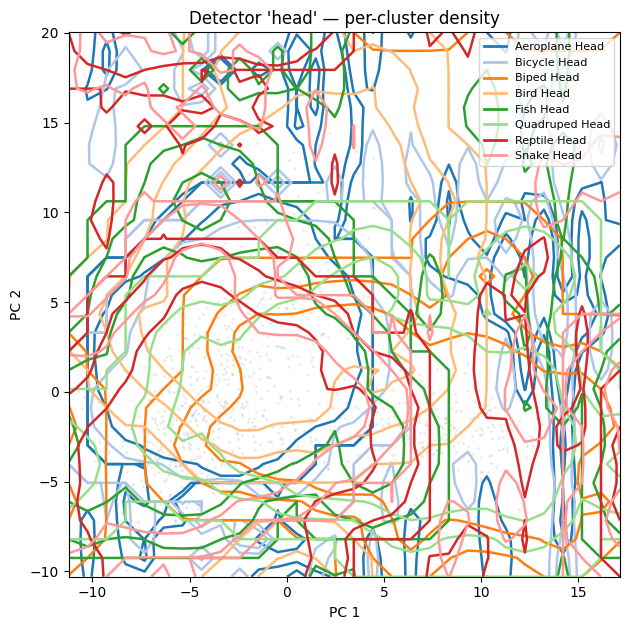

In [12]:


ds_vis = ds_te if 'ds_te' in globals() else ds_tr
_ = visualize_part_contours(
    "head", ds_vis, ens,
    max_per_cluster=200,
    bins=30,            # slightly fewer bins -> denser counts per bin
    sigma_bins=1,      # a touch more smoothing
    levels=(0.3, 0.5, 0.7),
    scatter_sample=800,
    save=True
)


/tmp/ipykernel_1125/3613147240.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


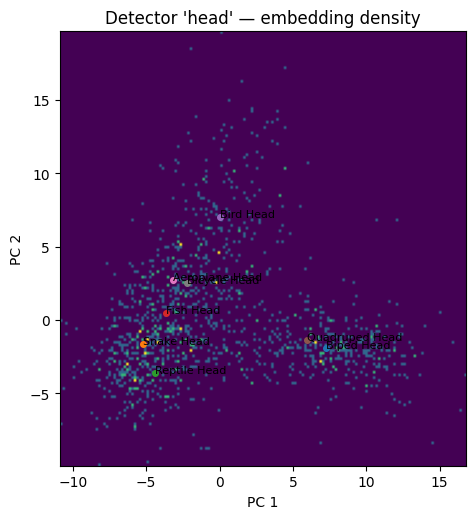

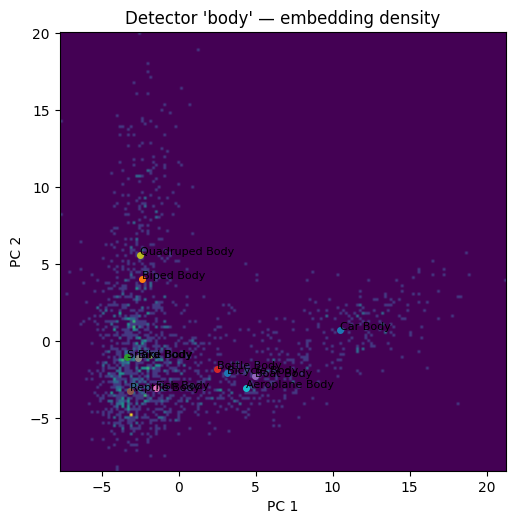

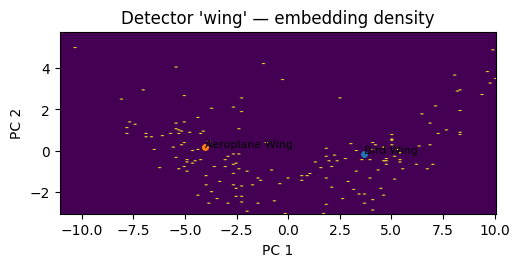

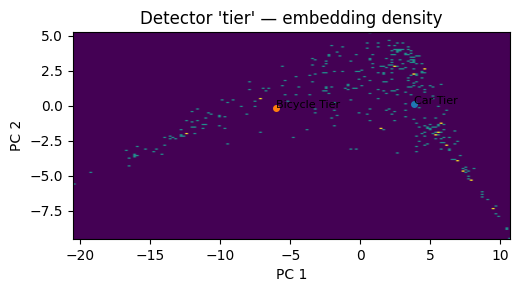

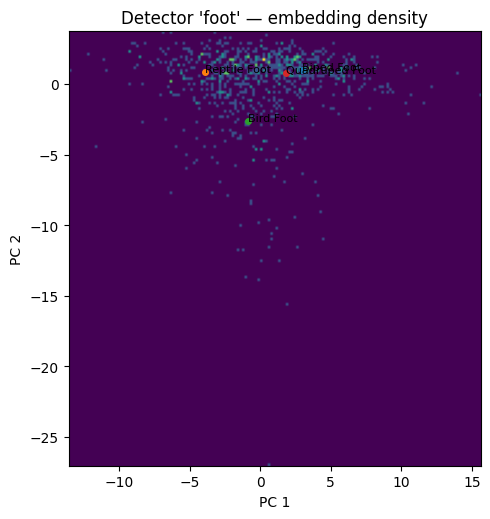

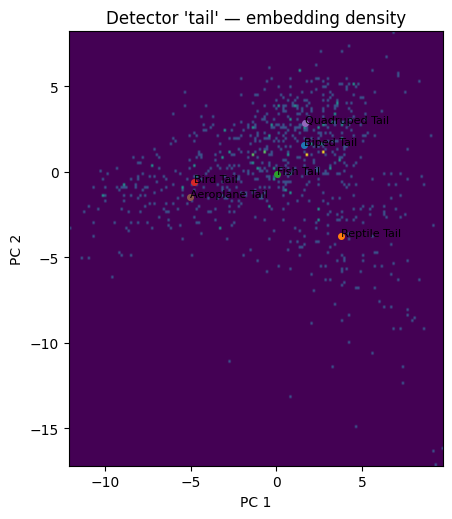

In [13]:
# --- FIXED Cell C: batch visualizer (now passes idxs) ---
parts_to_show = ["head", "body", "wing", "tier", "foot", "tail"]
max_per_cluster = 200   # lower = faster

for pn in parts_to_show:
    idxs, _ = sample_part_items(ds_te, pn, max_per_cluster=max_per_cluster)
    if not idxs:
        print(f"[{pn}] no samples, skipping.")
        continue
    # ✅ pass idxs here
    Z, y_true, names_true = embed_with_detector(ds_te, ens, pn, idxs, batch_size=512)
    Z2 = pca_2d(Z).numpy()

    # Optional centroid overlay (trim labels so the plot stays readable)
    from collections import defaultdict
    by_idx = defaultdict(list)
    for z, y, nm in zip(Z2, y_true.tolist(), names_true):
        by_idx[(y, nm)].append(z)
    centroids = []
    for (y, nm), pts in by_idx.items():
        arr = np.stack(pts, 0); mu = arr.mean(0)
        centroids.append((mu[0], mu[1], nm[:18]))

    plot_density(Z2, title=f"Detector '{pn}' — embedding density", bins=160, annotate_points=centroids[:25])


In [14]:
import numpy as np, torch, matplotlib.pyplot as plt
import torch.nn.functional as F

def _score_detectors(logits_list, priors, device, rule="confnorm"):
    """Return (B, D) scores for a batch using different routing rules."""
    B = logits_list[0].shape[0]
    S = []
    for d, lg in enumerate(logits_list):
        if lg is None:
            S.append(torch.zeros(B, device=device)); continue
        p = F.softmax(lg, 1)
        prior = priors[d].to(device) if isinstance(priors[d], torch.Tensor) else torch.tensor(priors[d], device=device)
        dot = (p * prior.view(1, -1)).sum(1)  # Σ p·π
        K = lg.size(1)

        if rule == "plain":
            s = dot
        elif rule == "maxprob":
            imax = p.argmax(1)
            s = p[torch.arange(B, device=device), imax] * prior[imax]
        elif rule == "confnorm":
            if K > 1:
                base = 1.0 / K
                conf = (p.max(1).values - base) / (1.0 - base)
                s = dot * conf.clamp(min=0.0)
            else:
                s = torch.zeros_like(dot)  # prevent K=1 auto-wins
        else:
            raise ValueError(f"unknown rule={rule}")
        S.append(s)
    return torch.stack(S, 0).transpose(0, 1)  # (B, D)

def routing_winner_histogram(ds, ens, max_images=1500, batch_size=512, rule="confnorm",
                             title=None):
    img_ids = sorted({it.image_id for it in ds.items})[:max_images]
    idxs = []
    per_img = {}
    for i, it in enumerate(ds.items):
        if it.image_id in img_ids:
            per_img.setdefault(it.image_id, []).append(i)
    for lst in per_img.values():
        idxs.extend(lst)

    part_names = list(ens.part_names_in_order)
    counts = np.zeros(len(part_names), dtype=np.int64)

    use_new = hasattr(torch, "amp") and hasattr(torch.amp, "autocast")
    ctx = (lambda: torch.amp.autocast(device_type="cuda", enabled=(ens.device.type=="cuda"))
           ) if use_new else (lambda: torch.cuda.amp.autocast(enabled=(ens.device.type=="cuda")))

    with torch.no_grad(), ctx():
        for s in range(0, len(idxs), batch_size):
            chunk = idxs[s:s+batch_size]
            xb = torch.cat([ds[j][0].unsqueeze(0) for j in chunk], 0).to(ens.device, non_blocking=True)
            zs_list, lg_list = ens.score_all(xb)
            S = _score_detectors(lg_list, ens.priors, ens.device, rule=rule)
            winners = S.argmax(1).cpu().numpy()
            for w in winners: counts[w] += 1

    total = counts.sum() if counts.sum() > 0 else 1
    pct = 100.0 * counts / total
    plt.figure(figsize=(10, 3))
    plt.bar(range(len(part_names)), counts)
    plt.xticks(range(len(part_names)), part_names, rotation=45, ha='right')
    plt.title(title or f"Routing winners per detector — rule: {rule}")
    plt.ylabel("# crop wins")
    plt.tight_layout(); plt.show()

    print("Share (%):")
    for name, p in zip(part_names, pct):
        print(f"{name:10s}: {p:5.1f}%")


/tmp/ipykernel_1125/2474874335.py:277: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(self.device.type=="cuda")):


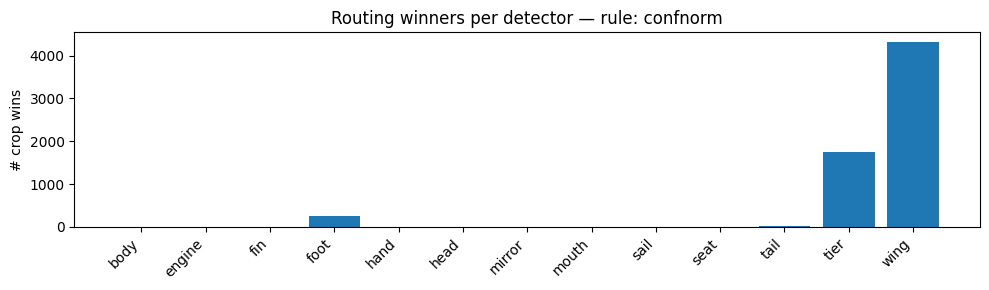

Share (%):
body      :   0.0%
engine    :   0.0%
fin       :   0.0%
foot      :   4.0%
hand      :   0.0%
head      :   0.0%
mirror    :   0.0%
mouth     :   0.0%
sail      :   0.0%
seat      :   0.0%
tail      :   0.4%
tier      :  27.4%
wing      :  68.1%


In [15]:
# Try the confidence-normalized rule
routing_winner_histogram(ds_te, ens, max_images=1500, batch_size=512, rule="confnorm")


In [17]:
import numpy as np, torch, matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D

# -------- utilities --------
def _pca_2d_fp32(t: torch.Tensor) -> np.ndarray:
    X = t.detach().to(torch.float32)
    X = X - X.mean(0, keepdim=True)
    # robust SVD for 2D projection
    U, S, Vh = torch.linalg.svd(X, full_matrices=False)
    return (X @ Vh[:2].T).cpu().numpy()

def _cluster_color_map(names):
    # stable color per cluster name (tab20 palette)
    cmap = plt.get_cmap("tab20")
    colors = {}
    for i, n in enumerate(sorted(names)):
        colors[n] = cmap(i % 20)
    return colors

def _sample_part_items(ds, part_name, max_per_cluster=250, seed=1337):
    by_cluster = defaultdict(list)
    for i, it in enumerate(ds.items):
        if it.part_canonical != part_name: 
            continue
        if it.cluster_name not in ds.detector_clusters.get(part_name, {}):
            continue
        by_cluster[it.cluster_name].append(i)
    rng = np.random.default_rng(seed)
    picked = []
    for cname, idxs in by_cluster.items():
        if len(idxs) > max_per_cluster:
            idxs = list(rng.choice(idxs, size=max_per_cluster, replace=False))
        picked.extend(idxs)
    return picked, by_cluster

def _embed_with_detector(ds, ens, part_name, idxs, batch_size=512):
    device = ens.device
    p2i = {p:i for i,p in enumerate(ens.part_names_in_order)}
    if part_name not in p2i:
        raise ValueError(f"Detector not found for '{part_name}'")
    d_idx = p2i[part_name]
    det = ens.detectors[d_idx].eval()

    feats, y_idx, y_name = [], [], []
    use_new = hasattr(torch, "amp") and hasattr(torch.amp, "autocast")
    ctx = (lambda: torch.amp.autocast(device_type="cuda", enabled=(device.type=="cuda"))
           ) if use_new else (lambda: torch.cuda.amp.autocast(enabled=(device.type=="cuda")))

    with torch.no_grad(), ctx():
        for s in range(0, len(idxs), batch_size):
            chunk = idxs[s:s+batch_size]
            xb = torch.cat([ds[j][0].unsqueeze(0) for j in chunk], 0).to(device, non_blocking=True)
            z, _ = det(xb)
            feats.append(z.detach().to(torch.float32).cpu())   # <-- fp32 for PCA
            for j in chunk:
                _, _, cidx, _ = ds[j]
                y_idx.append(int(cidx))
                y_name.append(ds.items[j].cluster_name)
    Z = torch.cat(feats, 0)
    # map idx->name from dataset
    inv = {v:k for k,v in ds.detector_clusters.get(part_name, {}).items()}
    # ensure label names match current indices
    idx_to_name = {int(i): inv.get(int(i), f"#{int(i)}") for i in set(y_idx)}
    return Z, np.array(y_idx, int), np.array([idx_to_name[i] for i in y_idx]), idx_to_name

def _smooth_hist2d(H, sigma_bins=1.0):
    # fast FFT Gaussian blur (NumPy only); sigma in bins
    if sigma_bins is None or sigma_bins <= 0: 
        return H
    ksize = max(3, int(np.ceil(sigma_bins * 6)) | 1)  # odd
    ax = np.arange(-ksize//2 + 1., ksize//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    K = np.exp(-(xx**2 + yy**2) / (2. * sigma_bins**2)); K /= K.sum()
    padK = np.zeros_like(H)
    kh, kw = K.shape
    ph, pw = kh//2, kw//2
    padK[:kh, :kw] = K
    padK = np.roll(np.roll(padK, -ph, axis=0), -pw, axis=1)
    fH = np.fft.rfftn(H, s=H.shape)
    fK = np.fft.rfftn(padK, s=H.shape)
    sm = np.fft.irfftn(fH * fK, s=H.shape).real
    return np.maximum(sm, 0)

# -------- main plotting function --------
def plot_part_clusters_clear(
    ds, ens, part_name,
    max_per_cluster=250,
    draw_contours=True,      # turn on/off density edges
    bins=160, sigma_bins=1.2, levels=(0.3, 0.5, 0.7),
    scatter_alpha=0.65, point_size=8, annotate_centroids=True,
    legend_top_k=20, save_path=None
):
    idxs, by_cluster = _sample_part_items(ds, part_name, max_per_cluster=max_per_cluster)
    if not idxs:
        print(f"[{part_name}] no samples found to plot."); 
        return None

    Z, y_idx, y_name, idx_to_name = _embed_with_detector(ds, ens, part_name, idxs)
    Z2 = _pca_2d_fp32(Z)
    unique_idx = sorted(set(y_idx))
    cluster_names = [idx_to_name[i] for i in unique_idx]
    cmap = _cluster_color_map(cluster_names)

    x, y = Z2[:,0], Z2[:,1]
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    padx = 0.03 * (xmax - xmin + 1e-6); pady = 0.03 * (ymax - ymin + 1e-6)
    xmin -= padx; xmax += padx; ymin -= pady; ymax += pady

    plt.figure(figsize=(7.0, 6.4))
    # background: light gray scatter of all points
    plt.scatter(x, y, s=2, alpha=0.12, linewidths=0, color="#888888")

    # per-cluster colored scatter
    handles, labels = [], []
    for i in unique_idx:
        name = idx_to_name[i]
        pts = Z2[y_idx==i]
        c = cmap[name]
        plt.scatter(pts[:,0], pts[:,1], s=point_size, alpha=scatter_alpha, linewidths=0, color=c, label=name)

    # optional per-cluster density edges (contours)
    if draw_contours:
        xedges = np.linspace(xmin, xmax, bins+1)
        yedges = np.linspace(ymin, ymax, bins+1)
        Xc, Yc = np.meshgrid(0.5*(xedges[:-1]+xedges[1:]), 0.5*(yedges[:-1]+yedges[1:]))
        for i in unique_idx:
            name = idx_to_name[i]
            c = cmap[name]
            pts = Z2[y_idx==i]
            if pts.shape[0] < 6: 
                continue
            H, _, _ = np.histogram2d(pts[:,0], pts[:,1], bins=[xedges, yedges])
            Hs = _smooth_hist2d(H, sigma_bins=sigma_bins)
            flat = Hs.ravel(); flat = flat[flat>0]
            if flat.size == 0: 
                continue
            lvl_vals = [np.quantile(flat, p) for p in levels if np.quantile(flat, p) > 0]
            if not lvl_vals: 
                continue
            plt.contour(Xc, Yc, Hs.T, levels=lvl_vals, colors=[c]*len(lvl_vals), linewidths=1.6)

    # centroids
    if annotate_centroids:
        for i in unique_idx:
            name = idx_to_name[i]
            pts = Z2[y_idx==i]
            if pts.shape[0] == 0: 
                continue
            mu = pts.mean(0)
            plt.scatter([mu[0]],[mu[1]], s=60, facecolor="none", edgecolor="k", linewidths=1.2)
            plt.text(mu[0], mu[1], name[:22], fontsize=8)

    # compact legend (top-K by sample count)
    sizes = [(idx_to_name[i], (y_idx==i).sum()) for i in unique_idx]
    sizes.sort(key=lambda x: -x[1])
    top_names = [n for n,_ in sizes[:legend_top_k]]
    legend_handles = [Line2D([0],[0], marker='o', linestyle='',
                             markersize=6, markerfacecolor=cmap[n], color=cmap[n]) for n in top_names]
    plt.legend(legend_handles, top_names, loc="upper right", fontsize=8, frameon=True, title="Clusters")

    plt.title(f"Detector '{part_name}': clusters in embedding (PCA 2D)")
    plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.xlim([xmin, xmax]); plt.ylim([ymin, ymax])
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=160)
        print("Saved:", save_path)
    plt.show()
    return True


/tmp/ipykernel_1125/2496652553.py:80: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  fH = np.fft.rfftn(H, s=H.shape)
/tmp/ipykernel_1125/2496652553.py:81: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  fK = np.fft.rfftn(padK, s=H.shape)
/tmp/ipykernel_1125/2496652553.py:82: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will r

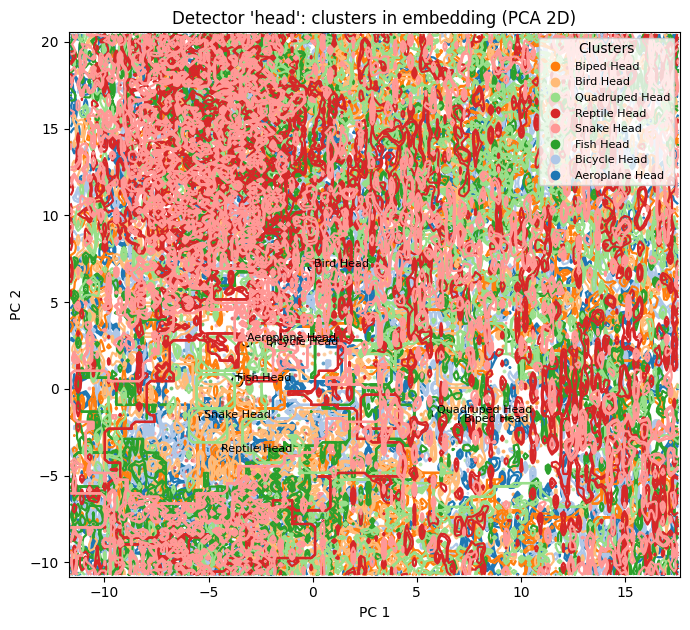

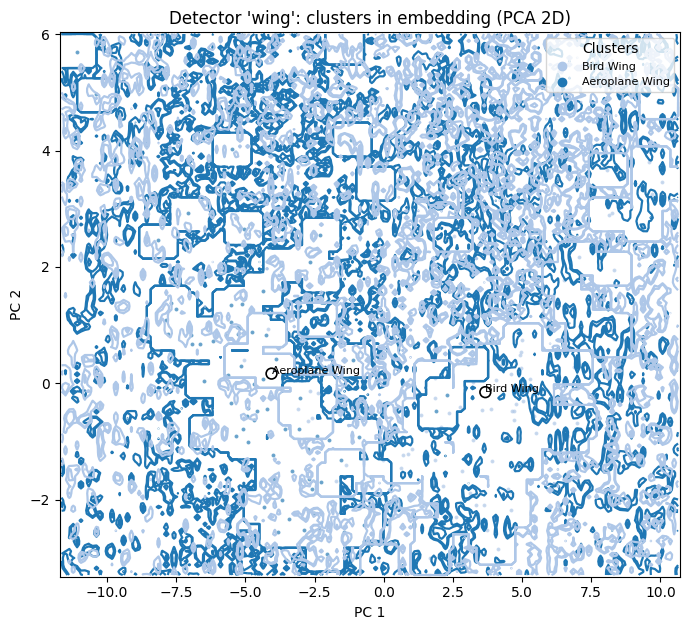

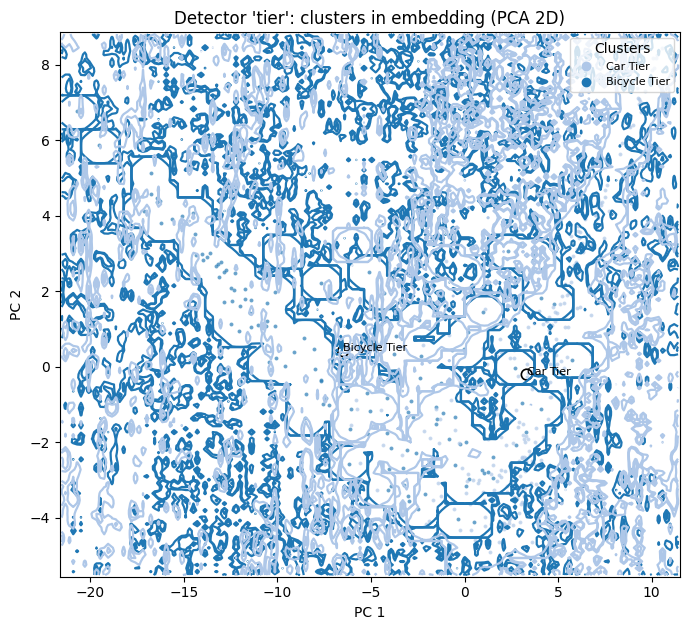

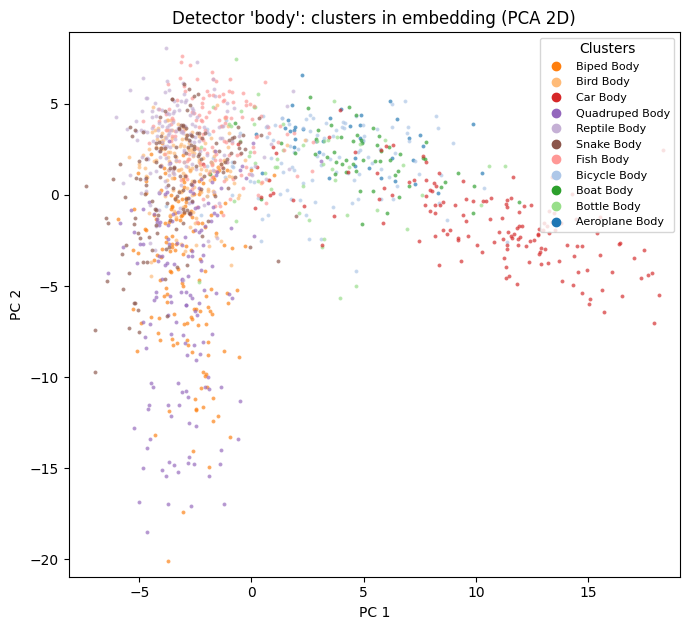

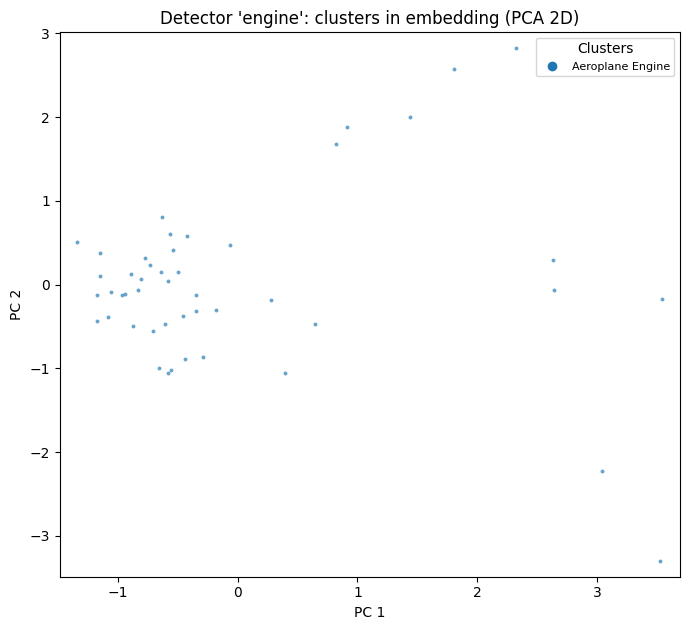

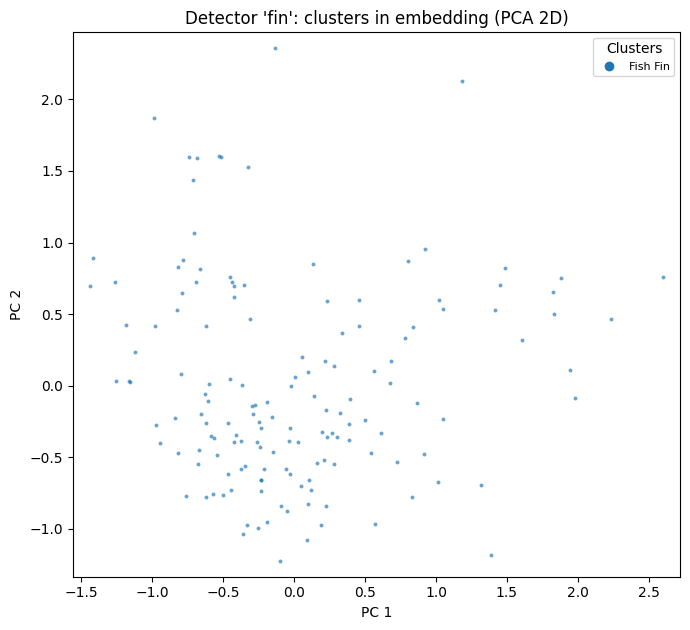

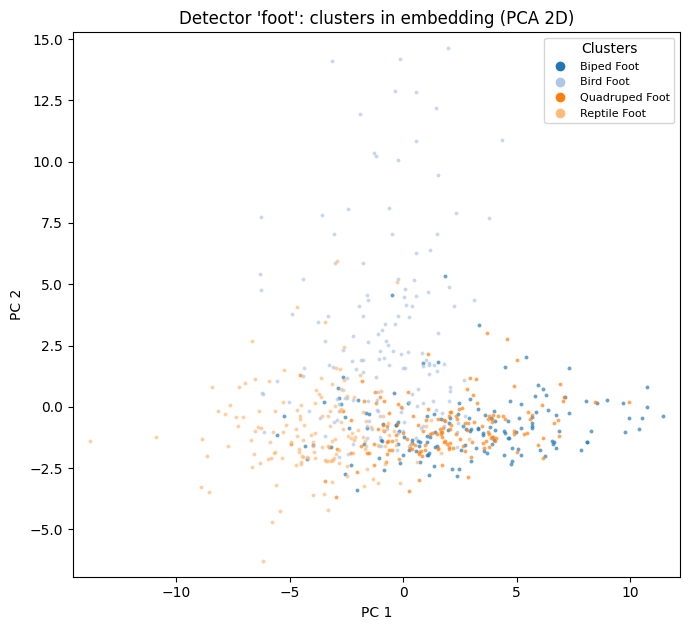

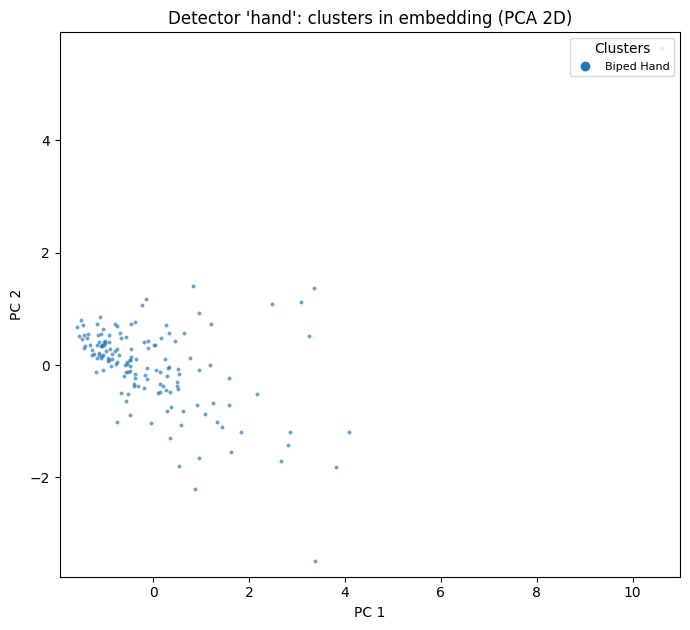

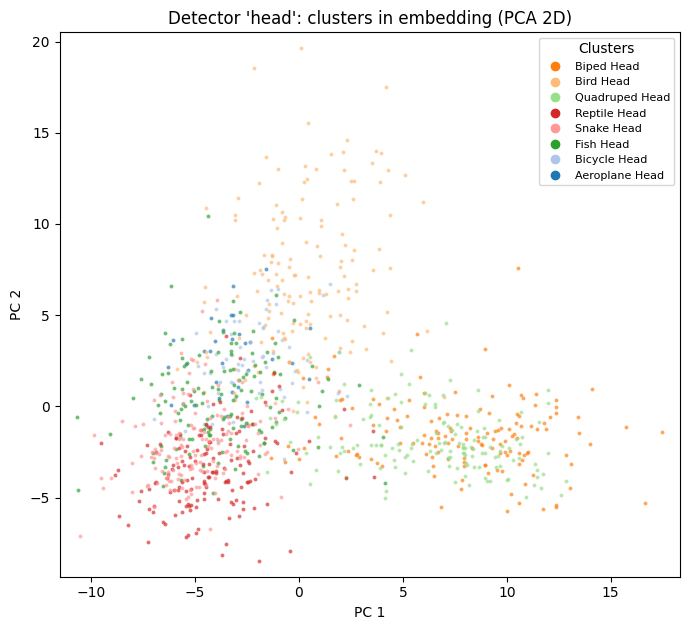

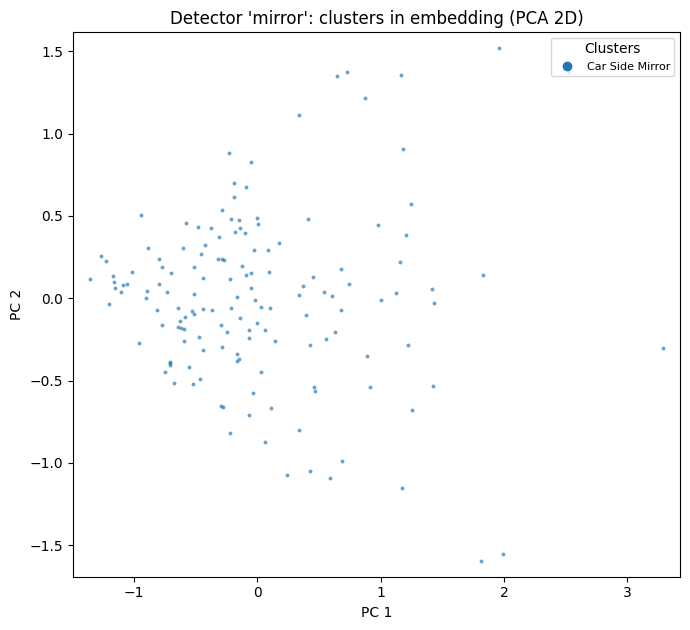

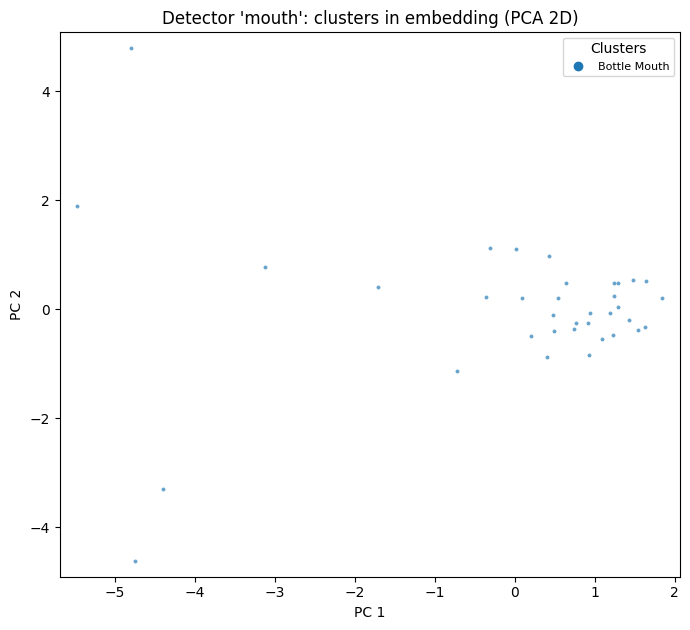

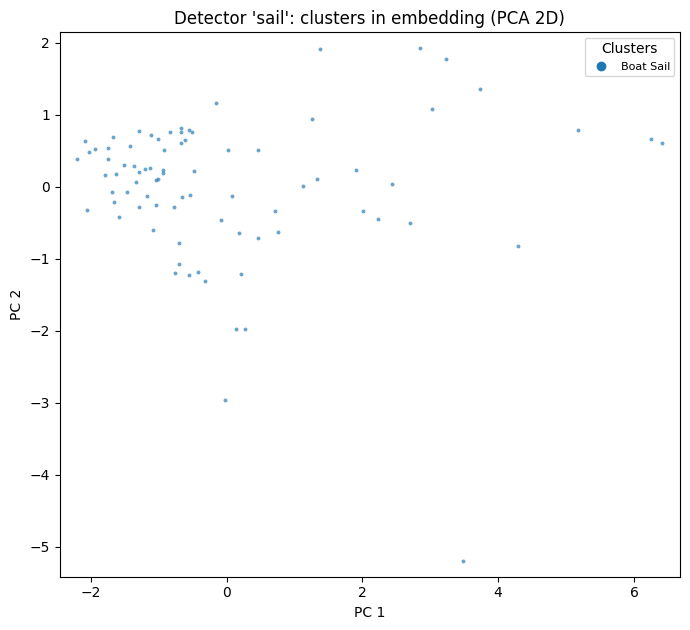

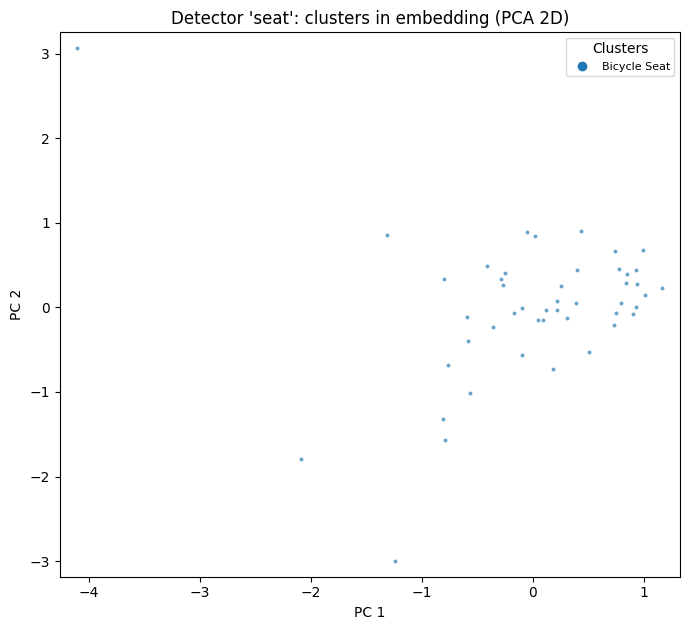

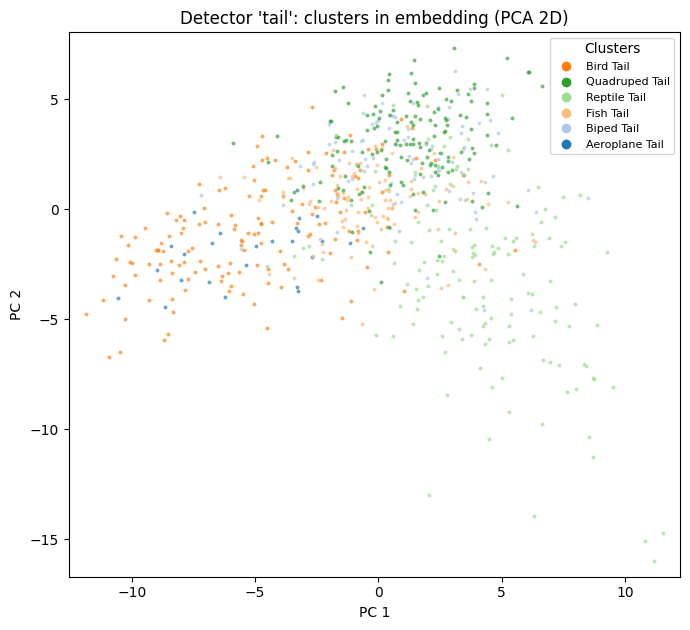

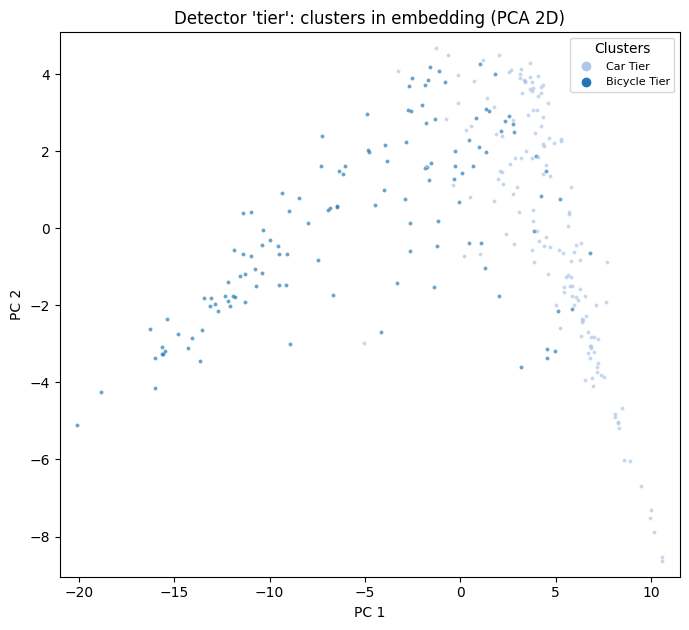

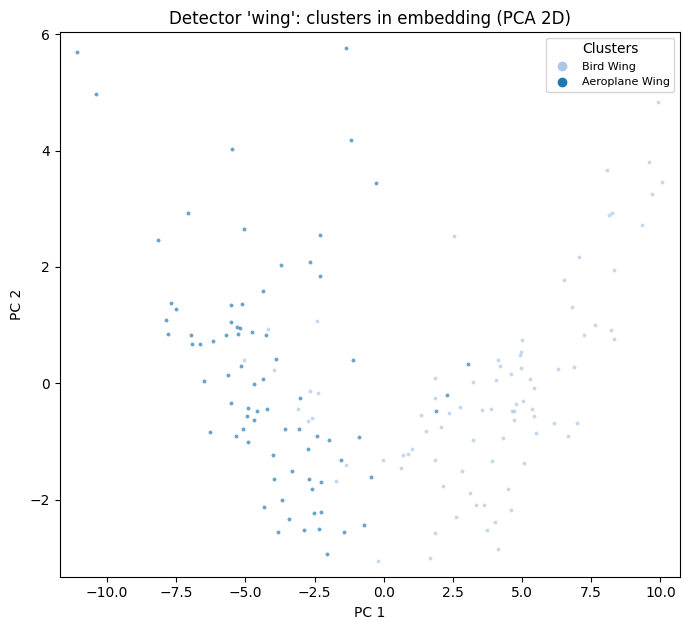

In [18]:
# Fastest on test split:
plot_part_clusters_clear(ds_te, ens, "head",  max_per_cluster=200, draw_contours=True)
plot_part_clusters_clear(ds_te, ens, "wing",  max_per_cluster=250, draw_contours=True)
plot_part_clusters_clear(ds_te, ens, "tier",  max_per_cluster=250, draw_contours=True)

# Grid over many parts (no contours for speed)
for pn in ens.part_names_in_order:
    try:
        plot_part_clusters_clear(ds_te, ens, pn, max_per_cluster=150, draw_contours=False, annotate_centroids=False)
    except Exception as e:
        print(f"[{pn}] skipped:", e)


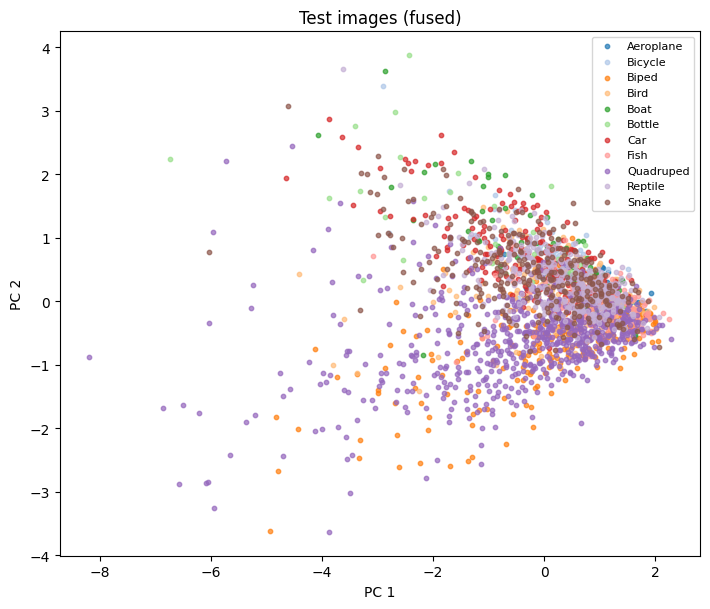

In [20]:
import numpy as np, torch, matplotlib.pyplot as plt

def plot_image_embedding_2d(
    ds, ens, X=None, ids=None, title="Image-level embedding (PCA 2D)",
    max_images=2000, point_size=10, alpha=0.7
):
    # Use precomputed fused arrays if available; else fuse a subset quickly.
    try:
        if X is not None and ids is not None:
            y, label_map = image_labels_from_supercategory(ds, ids)
            names = {v:k for k,v in label_map.items()}
            Z2 = _pca_2d_fp32(torch.as_tensor(X))
        else:
            # fuse a subset
            all_ids = sorted({it.image_id for it in ds.items})[:max_images]
            from alex_part_pipeline import fuse_image_embeddings
            X, ids = fuse_image_embeddings(ds, ens, image_ids=all_ids, batch_size=256)
            y, label_map = image_labels_from_supercategory(ds, ids)
            names = {v:k for k,v in label_map.items()}
            Z2 = _pca_2d_fp32(torch.as_tensor(X))
    except NameError:
        raise RuntimeError("Need image_labels_from_supercategory and (optionally) fuse_image_embeddings imported.")

    y = np.asarray(y, dtype=int)
    uniq = sorted(set(y))
    cmap = plt.get_cmap("tab20")
    plt.figure(figsize=(7.2, 6.2))
    for i, c in enumerate(uniq):
        pts = Z2[y==c]
        if pts.shape[0] == 0: continue
        plt.scatter(pts[:,0], pts[:,1], s=point_size, alpha=alpha, color=cmap(i % 20), label=names.get(c, str(c)))
    plt.title(title); plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.legend(loc="best", fontsize=8, frameon=True)
    plt.tight_layout(); plt.show()

# Examples:
plot_image_embedding_2d(ds_te, ens, X=Xte, ids=ids_te, title="Test images (fused)")
# plot_image_embedding_2d(ds_te, ens, X=None, ids=None, max_images=1500)


In [21]:
# ==== Per-part detector performance table (from alex_ckpts) ====
import os, json, torch, math
import numpy as np
import pandas as pd

CKPT_DIR = "alex_ckpts"  # change if you used a different folder
manifest_path = os.path.join(CKPT_DIR, "manifest.json")
assert os.path.exists(manifest_path), f"Not found: {manifest_path}"

man = json.load(open(manifest_path))

rows = []
for det in man.get("detectors", []):
    fpath = os.path.join(CKPT_DIR, det["file"])
    if not os.path.exists(fpath):
        print("Missing:", fpath)
        continue
    pkg = torch.load(fpath, map_location="cpu")
    part = pkg.get("part", det.get("part", os.path.splitext(det["file"])[0].replace("det_","")))
    emb_dim = pkg.get("emb_dim", det.get("emb_dim", None))
    num_classes = pkg.get("num_classes", det.get("num_classes", None))
    inv_clusters = pkg.get("inv_clusters", {})
    clusters = pkg.get("clusters", {v:k for k,v in inv_clusters.items()})
    K = num_classes if num_classes is not None else len(inv_clusters) or len(clusters)

    logs = pkg.get("logs", {}) or {}
    tr_loss = logs.get("train_loss", [])
    tr_acc  = logs.get("train_acc", [])
    va_loss = logs.get("val_loss", [])
    va_acc  = logs.get("val_acc", [])
    best_ep = logs.get("best_epoch", None)
    best_va = logs.get("best_val_acc", None)

    last_ep = max(len(tr_loss), len(tr_acc), len(va_loss), len(va_acc))
    last_va = (va_acc[-1] if len(va_acc) else np.nan)
    last_tr = (tr_acc[-1] if len(tr_acc) else np.nan)

    # dataset supports (optional): counts crops per part in train/test if ds_* exist
    train_crops = np.nan
    test_crops  = np.nan
    try:
        train_crops = sum(1 for it in ds_tr.items if getattr(it, "part_canonical", None) == part)
    except Exception:
        pass
    try:
        test_crops = sum(1 for it in ds_te.items if getattr(it, "part_canonical", None) == part)
    except Exception:
        pass

    rows.append({
        "part": part,
        "#clusters": int(K),
        "emb_dim": emb_dim,
        "train_crops": train_crops,
        "test_crops":  test_crops,
        "best_val_acc": float(best_va) if best_va is not None else np.nan,
        "last_val_acc": float(last_va) if not math.isnan(last_va) else np.nan,
        "last_train_acc": float(last_tr) if not math.isnan(last_tr) else np.nan,
        "best_epoch": best_ep,
        "epochs_logged": last_ep,
    })

df = pd.DataFrame(rows).sort_values(by=["best_val_acc","last_val_acc"], ascending=False, na_position="last")
display_cols = ["part","#clusters","train_crops","test_crops","best_val_acc","last_val_acc","last_train_acc","best_epoch","epochs_logged","emb_dim"]
df = df[display_cols]

# pretty print
pd.set_option("display.max_rows", 1000)
print(df.to_string(index=False, justify="left", col_space=10))

# save CSV next to checkpoints
out_csv = os.path.join(CKPT_DIR, "detector_performance_table.csv")
df.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)


part        #clusters  train_crops  test_crops  best_val_acc  last_val_acc  last_train_acc  best_epoch  epochs_logged  emb_dim  
   fin      1          3163         349        1.000000      1.000000      1.000000         1          10             128       
  hand      1          3482         414        1.000000      1.000000      1.000000         1          10             128       
 mouth      1           340          36        1.000000      1.000000      1.000000         1          10             128       
  sail      1           680          81        1.000000      1.000000      1.000000         1          10             128       
engine      1           355          47        1.000000      1.000000      1.000000         1          10             128       
mirror      1          1406         159        1.000000      1.000000      1.000000         1          10             128       
  seat      1           369          47        1.000000      1.000000      1.000000         1    